In [1]:
import numpy as np
from scipy.optimize import newton
import CoolProp.CoolProp as cp
import fluids as fl
from Pumps.ZX115.ZX115PumpFit import Pa4m3s
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq # <-- Agrega esto a tus imports arriba

In [2]:
def nu_from_T(T):
    return  1.3686547347844438e-06*np.exp(1913.7989961446747/T)

In [ ]:
# Parámetros geométricos y de accesorios
K_inlet = fl.fittings.entrance_sharp()
K_valve = 0.
m1_din = 10e-3
m1_l = 10e-3
m2_din = 12e-3
m2_l = 22e-3

A_m1 = np.pi * (m1_din**2) / 4
A_m2 = np.pi * (m2_din**2) / 4

e_plastic = fl.friction.material_roughness("Plastic")

# Definición del tanque cilíndrico acostado: Diámetro = 70mm, Largo = 100mm
L_tanque = 100e-3
tanque = fl.TANK(D=70e-3, L=L_tanque, horizontal=True, sideA=None, sideB=None)

In [4]:
def evaluar_regimen_sistema_vaciado(Q, mu, rho, hi):
    if Q <= 0:
        return 0.0

    # Sección Final: Tanque horizontal
    Vi = tanque.V_from_h(hi)
    Ai = tanque.A_cross_sectional(hi)
    
    if Ai < 1e-5:
        v0 = 0.0
    else:
        v0 = Q / Ai
        
    # Sección 1: Manguera 1
    v1 = Q / A_m1
    h1 = 9e-3
    Re1 = fl.Reynolds(V=v1, D=m1_din, rho=rho, mu=mu)
    loss_inlet = K_inlet * (rho * v1**2 / 2)
    fd1 = fl.friction_factor(Re=Re1, eD=e_plastic/m1_din) 
    loss1 = fd1 * (m1_l / m1_din) * (rho * v1**2 / 2)
    loss_valve = K_valve * (rho * v1**2 / 2)

    # Sección 2: Manguera 2
    v2 = Q / A_m2
    Re2 = fl.Reynolds(V=v2, D=m2_din, rho=rho, mu=mu)
    fd2 = fl.friction_factor(Re=Re2, eD=e_plastic/m2_din) 
    loss2 = fd2 * (m2_l / m2_din) * (rho * v2**2 / 2)
    h2 = 0
    
    dh = h2 - (h1 + hi)
    delta_p = (loss1 + loss2 + loss_inlet + loss_valve 
               + (rho * v2**2 / 2 - rho * v0**2 / 2)
               + dh * rho * 9.81)

    return delta_p

In [6]:
from scipy.optimize import newton
import CoolProp.CoolProp as cp

# =========================================================================
# 1. PROPIEDADES DEL FLUIDO
# =========================================================================
fluido = "Water"
T_celcius = 16               # Temperatura en °C
P_pascales = 101325.0        # Presión absoluta en Pa (1 atm)
T_kelvin = T_celcius + 273.15   

# Cálculo exacto de Densidad (rho) y Viscosidad Dinámica (mu)
rho_agua = cp.PropsSI('D', 'T', T_kelvin, 'P', P_pascales, fluido)   # kg/m³
mu_agua = cp.PropsSI('V', 'T', T_kelvin, 'P', P_pascales, fluido)    # Pa*s

# =========================================================================
# 2. CONDICIONES HIDROSTÁTICAS
# =========================================================================
hi_actual = 0.05    # Altura inicial de agua en el tanque (m)

# =========================================================================
# 3. FUNCIÓN OBJETIVO PARA EL SOLVER
# =========================================================================
def funcion_objetivo_gravedad(Q):
    # Newton-Raphson buscará el caudal Q donde la función devuelva 0
    return evaluar_regimen_sistema_vaciado(Q, mu_agua, rho_agua, hi_actual)

# =========================================================================
# 4. EJECUCIÓN DEL MÉTODO NUMÉRICO
# =========================================================================
# Usamos un caudal estimado inicial bajo (gravedad)
Q_inicial = 5e-5 

try:
    # Resolvemos la ecuación encontrando la raíz
    Q_operacion = newton(funcion_objetivo_gravedad, Q_inicial)
    
    print("==========================================================")
    print("      PUNTO DE OPERACIÓN ENCONTRADO (VACIADO POR GRAVEDAD)")
    print("==========================================================")
    print(f"Caudal de drenaje (Q)   : {Q_operacion:.6e} m³/s")
    print(f"Caudal en Litros/min    : {Q_operacion * 60000:.3f} L/min")
    print("==========================================================")
    
except RuntimeError as e:
    print(f"El método numérico no logró converger: {e}")

      PUNTO DE OPERACIÓN ENCONTRADO (VACIADO POR GRAVEDAD)
Caudal de drenaje (Q)   : 3.545201e-05 m³/s
Caudal en Litros/min    : 2.127 L/min


  INICIANDO SIMULACIÓN TRANSITORIA DE VACIADO (GRAVEDAD)...
4709.1774745484145
4637.441399120128
4594.5471154121
4558.291230250486
4525.67799926365
4495.484256129376
4467.049841278423
4439.9802361260645
4414.004689295245
4388.932346312265
4364.622189946134
4340.966077663728
4317.878681401909
4295.29114642763
4273.146891245005
4251.3987116262415
4230.0067175915765
4208.936823954994
4188.159621127994
4167.649514499856
4147.384058009422
4127.343215188539
4107.508641537806
4087.864474120371
4068.3966141181913
4049.092283661549
4029.9397416278634
4010.92735634205
3992.045368558389
3973.28501698462
3954.6381568036154
3936.096080096588
3917.6515571850687
3899.298283401172
3881.03000562172
3862.8397908580578
3844.722464087831
3826.673266413176
3808.6862918683673
3790.756775624494
3772.8808858261564
3755.053744591613
3737.270840910581
3719.5290160024606
3701.824025253192
3684.1517397700654
3666.509521382581
3648.893326717531
3631.2996069004917
3613.7260643518293
3596.1685968121565
3578.62438436

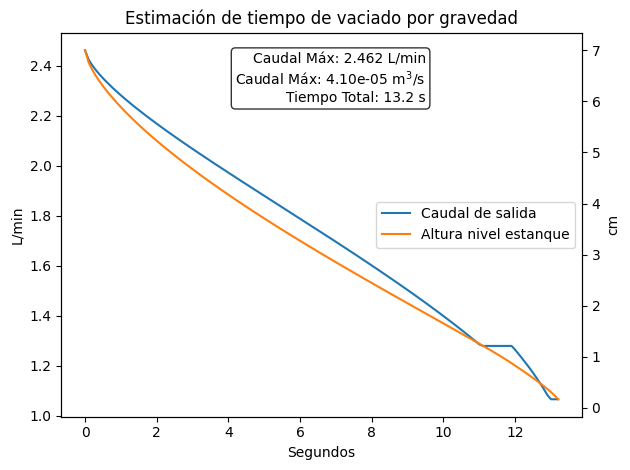

In [7]:
# =========================================================================
# 1. PARÁMETROS INICIALES (VACIADO)
# =========================================================================
dt = 0.1
t_actual = 0.0
radio_tanque = 35e-3
# Asumimos que partes con el tanque lleno o hasta una altura inicial conocida
h_tanque_t = radio_tanque * 2  # Ejemplo: tanque lleno (diámetro completo)
V_tanque_t = tanque.V_from_h(h_tanque_t)

hist_t_vac, hist_Q_vac, hist_h_tan_vac, hist_V_tan_vac = [], [], [], []

# Estimación inicial baja porque es por gravedad
Q_estimado = 5e-5 

print("==========================================================")
print("  INICIANDO SIMULACIÓN TRANSITORIA DE VACIADO (GRAVEDAD)...")
print("==========================================================")

# =========================================================================
# 2. BUCLE DE INTEGRACIÓN NUMÉRICA (VACIADO)
# =========================================================================
# Se detiene cuando queda menos de 1 mm de agua
while h_tanque_t > 0.001: 
    
    # La función objetivo ahora solo busca que Gravedad - Fricción = 0
    def funcion_transitoria_vaciado(Q):
        return evaluar_regimen_sistema_vaciado(Q, mu_agua, rho_agua, h_tanque_t)
        
    try:
        # Usamos brentq acorralando el caudal entre 1e-10 m3/s (casi cero) 
        # y 1e-3 m3/s (60 L/min, un límite superior exagerado para asegurar que la raíz esté al medio).
        Q_actual = brentq(funcion_transitoria_vaciado, 1e-10, 1e-3)
        Q_estimado = Q_actual 
        
        Re1 = fl.Reynolds(V=Q_actual/A_m1, D=m1_din, rho=rho_agua, mu=mu_agua)
        print(Re1)
            
    except ValueError:
        # Brent arroja ValueError si la presión de la gravedad no logra superar la fricción estática
        print(f"Flujo detenido en t = {t_actual:.1f} s (No hay suficiente altura para vencer la resistencia)")
        break
            
        
    # Guardamos historia
    hist_t_vac.append(t_actual)
    hist_Q_vac.append(Q_actual * 60000)      # L/min
    hist_h_tan_vac.append(h_tanque_t * 100)  # cm
    hist_V_tan_vac.append(V_tanque_t * 1e6)  # ml (opcional)
    
    # Avanzamos un dt (Ahora RESTAMOS el volumen al tanque)
    V_desplazado = Q_actual * dt
    V_tanque_t -= V_desplazado
    h_tanque_t = tanque.h_from_V(V_tanque_t)
    t_actual += dt

# =========================================================================
# 3. RESULTADOS FINALES
# =========================================================================
if hist_t_vac:
    t_final_vac = hist_t_vac[-1]
    Q_max_vac = max(hist_Q_vac)

    print("\n==========================================================")
    print("             REPORTE DE VACIADO FINALIZADO                ")
    print("==========================================================")
    print(f"Tiempo total de drenaje : {t_final_vac:.1f} segundos")
    print(f"Caudal máximo de salida : {Q_max_vac:.3f} L/min")
    print("==========================================================\n")

# =========================================================================
# 4. GRÁFICOS (VACIADO)
# =========================================================================
fig2, ax1 = plt.subplots()

# Eje izquierdo para Caudal
linea1 = ax1.plot(hist_t_vac, hist_Q_vac, color='tab:blue', label='Caudal de salida') 
ax1.set_ylabel('L/min')
ax1.set_title('Estimación de tiempo de vaciado por gravedad')
ax1.set_xlabel('Segundos')

# Eje derecho para la Altura
ax2 = ax1.twinx()
linea2 = ax2.plot(hist_t_vac, hist_h_tan_vac, color='tab:orange', label='Altura nivel estanque')
ax2.set_ylabel('cm')

# Cuadro de texto flotante
texto_info_vac = (
    f"Caudal Máx: {Q_max_vac:.3f} L/min\n"
    f"Caudal Máx: {Q_max_vac / 60000:.2e} m$^3$/s\n"
    f"Tiempo Total: {t_final_vac:.1f} s"
)

ax1.text(0.7, 0.95, texto_info_vac, 
         transform=ax1.transAxes, 
         ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))

# Leyenda unificada
lineas = linea1 + linea2
etiquetas = [l.get_label() for l in lineas]
ax1.legend(lineas, etiquetas, loc='center right')

plt.tight_layout()
plt.show()

In [ ]:
0.7/0.1477

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# 1. Definir el rango de caudales solicitado (0.000005 m3/s a 0.000021 m3/s)
caudales = np.linspace(0.000005, 0.000021, 100)

# Variables de entorno (Asegúrate de que coincidan con las de tu Jupyter)
# hi, Vf = 0.2 , 1e-6
# mu_agua, rho_agua = 0.001, 1000 
# d_tuberia = 12.7e-3 # Diámetro de 12.7 mm

# 2. Generar las curvas
bomba = np.array([Pa4m3s(q) for q in caudales])
sistema = np.array([evaluar_regimen_sistema(q, mu_agua, rho_agua, hi, Vf) for q in caudales])

# 3. Encontrar matemáticamente el Punto de Operación (Intersección)
def buscar_interseccion(q):
    return evaluar_regimen_sistema(q[0], mu_agua, rho_agua, hi, Vf) - Pa4m3s(q[0])

Q_op = fsolve(buscar_interseccion, 0.000015)[0] 
P_op = Pa4m3s(Q_op)
Q_op_Lmin = Q_op * 60 * 1000

# -------------------------------------------------------------
# NUEVO: Cálculo exacto del punto de singularidad (Re = 2040)
# -------------------------------------------------------------
Q_crit_m3s = (2040 * np.pi * mu_agua * m1_din) / (4 * rho_agua)
Q_crit_Lmin = Q_crit_m3s * 60 * 1000
P_crit = evaluar_regimen_sistema(Q_crit_m3s, mu_agua, rho_agua, hi, Vf)

# 4. Configurar el gráfico
plt.figure()
plt.plot(caudales * 60 * 1000, sistema, label="Sistema")
plt.plot(caudales * 60 * 1000, bomba, label="Bomba ZX115")
plt.ylabel("Pa")
plt.xlabel("L/min")

# Ajuste de límites
plt.xlim(0.8, 1.4) 
plt.ylim(0, 3000)

# Líneas del punto de operación
plt.vlines(Q_op_Lmin, ymin=0, ymax=P_op, color="green", linestyle="--")

# Cuadro de texto Punto de Operación
texto_anotacion = (
    "Punto de Operación:\n"
    f"Caudal: {Q_op_Lmin:.3f} L/min\n"
    f"Caudal: {Q_op:.2e} m$^3$/s\n"
)

plt.annotate(
    texto_anotacion,
    xy=(Q_op_Lmin, P_op),               
    xytext=(Q_op_Lmin - 0.3, P_op + 300), 
    arrowprops=dict(arrowstyle="->", color="black"),
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", alpha=0.9)
)

# -------------------------------------------------------------
# NUEVO: Marcador y anotación de la Singularidad (Re=2040)
# -------------------------------------------------------------
# Dibujamos un punto rojo en la curva del sistema
plt.plot(Q_crit_Lmin, P_crit, marker='o', markersize=6, color="red", zorder=5)
plt.vlines(Q_crit_Lmin, ymin=0, ymax=P_crit, color="red", linestyle=":", alpha=0.6)

texto_singularidad = (
    "Salto de Transición\n"
    "(Re $\\approx$ 2040)\n"
    f"{Q_crit_Lmin:.3f} L/min"
)

plt.annotate(
    texto_singularidad,
    xy=(Q_crit_Lmin, P_crit),               
    xytext=(Q_crit_Lmin - 0.05, P_crit + 200), # Ajustado a la derecha para que no choque
    arrowprops=dict(arrowstyle="->", color="red"),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#ffeeee", edgecolor="red", alpha=0.9)
)

plt.legend()
plt.show()

In [ ]:
print(fl.friction_factor(2, e_plastic/m1_din) )